# 02 — Workforce Analysis

This notebook analyses the organisation's active trainer pool and evaluates workforce vulnerability for each course-location combination.

The analysis examines:

1. trainer coverage by course, professional area, and location;
2. trainer flexibility across courses and training centres;
3. workforce profiles based on specialisation and mobility;
4. redundancy, backup capacity, and dependence on shared trainers;
5. relative workforce vulnerability;
6. the main structural risk affecting each course-location combination.

The final output is a workforce vulnerability score that contributes to the overall hiring-priority model.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

## Project configuration

The analysis reads validated data from `data/processed/` and exports the workforce features and scores to `data/scores/`.

Keeping processed data and analytical scores in separate directories preserves the different stages of the workflow and makes the transformations easier to audit.

In [2]:
PROCESSED_DATA_DIR = Path("../data/processed")

SCORES_DATA_DIR = Path("../data/scores")

## Data import

Three processed datasets are used:

- `trainers_course.csv`: courses for which each trainer is registered;
- `trainers_local.csv`: locations in which each trainer is registered;
- `info_actions.csv`: course names, professional areas, reference durations, and catalogue status.

Together, these datasets make it possible to reconstruct the potential trainer pool for each active course-location combination.

In [3]:
trainers_course_df = pd.read_csv(PROCESSED_DATA_DIR / "trainers_course.csv", sep=",", encoding="utf-8")

trainers_local_df = pd.read_csv(PROCESSED_DATA_DIR / "trainers_local.csv", sep=",", encoding="utf-8")

info_actions_df = pd.read_csv(PROCESSED_DATA_DIR / "info_actions.csv", sep=",", encoding="utf-8")

## Analytical workforce base

Trainer-course and trainer-location relationships are combined to create all course-location combinations for which each trainer is potentially eligible.

Course information is then added, inactive catalogue courses are excluded, and duplicated trainer-course-location relationships are removed.

The resulting dataset represents potential trainer eligibility rather than confirmed availability or historical assignment.

In [4]:
workforce_df = trainers_course_df.merge(
    trainers_local_df, how="inner", on="trainer_id", validate="many_to_many"
)

workforce_df = workforce_df.merge(
    info_actions_df, how="inner", on="course_id", validate="many_to_one"
)

workforce_df = workforce_df.loc[workforce_df["active"]].drop_duplicates(subset=["trainer_id", "course_id", "local"])

workforce_df

,trainer_id,course_id,local,course_name,course_area,total_hours,active
0,1,CYB,Centro 4,Cibersegurança Básica,Informática,16,True
1,1,PBI,Centro 4,Power BI e Visualização de Dados,Informática,25,True
2,2,CYB,Centro 2,Cibersegurança Básica,Informática,16,True
3,2,PBI,Centro 2,Power BI e Visualização de Dados,Informática,25,True
4,3,GER,Centro 5,Geriatria e Apoio ao Idoso,Saúde,50,True
...,...,...,...,...,...,...,...
381,179,ING,Centro 5,Inglês Profissional,Línguas,30,True
382,180,VND,Centro 3,Vendas e Negociação,Comercial,16,True
383,181,SOC,Centro 2,Socorrismo Básico,Saúde e Segurança,16,True
384,182,HOT,Centro 4,Housekeeping e Operações Hoteleiras,Turismo,25,True


## Workforce overview

The analytical workforce contains 183 trainers registered across 24 active courses and 5 training centres.

These totals describe the overall trainer pool, but they do not indicate whether coverage is evenly distributed. The following analyses therefore examine trainer availability at course, location, professional-area, and course-location levels.

In [5]:
total_trainers = workforce_df["trainer_id"].nunique()
total_courses = workforce_df["course_id"].nunique()
total_locals = workforce_df["local"].nunique()

print(
    f"""
Total trainers: {total_trainers}
Total courses: {total_courses}
Total locals: {total_locals}
""".strip()
)

Total trainers: 183
Total courses: 24
Total locals: 5


## Distribution of trainer coverage

Trainer coverage is examined from four complementary perspectives:

- total trainers registered for each course;
- total trainers available in each location;
- total trainers associated with each professional area;
- trainer count for each individual course-location combination.

The same trainer may appear in several courses or locations. Consequently, these counts represent potential coverage within each analytical grouping and should not be summed to obtain an organisational total.

In [6]:
course_trainer_count = (
    workforce_df.groupby(["course_id", "course_name"])
    .agg(
        trainer_count=("trainer_id", "nunique")
    )
    .assign(
        diff_mean= lambda df: df["trainer_count"].sub(df["trainer_count"].mean()).round(2)
    )
    .sort_values(by="trainer_count", ascending=False)
    .reset_index()
)

course_trainer_count

,course_id,course_name,trainer_count,diff_mean
0,PBI,Power BI e Visualização de Dados,19,5.04
1,GER,Geriatria e Apoio ao Idoso,17,3.04
2,ING,Inglês Profissional,16,2.04
3,FOR,Formação Pedagógica Inicial de Formadores,16,2.04
4,CYB,Cibersegurança Básica,15,1.04
5,PRO,Gestão de Projetos,15,1.04
6,PRI,Primeiros Socorros,15,1.04
7,HAC,Higiene e Segurança Alimentar,15,1.04
8,EMP,Empilhadores e Movimentação de Cargas,14,0.04
9,LID,Liderança e Comunicação,14,0.04


In [7]:
course_trainer_count.describe().round(2)

,trainer_count,diff_mean
count,24.00,24.00
mean,13.96,-0.00
std,1.85,1.85
min,11.00,-2.96
25%,13.00,-0.96
50%,14.00,0.04
75%,15.00,1.04
max,19.00,5.04


In [8]:
local_trainer_count = (
    workforce_df.groupby("local")
    .agg(
        trainer_count=("trainer_id", "nunique")
    )
    .assign(
        pct_trainer= lambda df: df["trainer_count"].div(total_trainers).mul(100).round(2)
    )
    .sort_values(by="trainer_count", ascending=False)
    .reset_index()
)

local_trainer_count

,local,trainer_count,pct_trainer
0,Centro 2,44,24.04
1,Centro 3,44,24.04
2,Centro 5,41,22.40
3,Centro 1,39,21.31
4,Centro 4,39,21.31


In [9]:
area_trainers_count = (
    workforce_df.groupby("course_area")
    .agg(
        trainer_count=("trainer_id", "nunique")
    )
    .assign(
        pct_trainer= lambda df: df["trainer_count"].div(total_trainers).mul(100).round(2)
    )
    .sort_values(by="trainer_count", ascending=False)
    .reset_index()
)

area_trainers_count

,course_area,trainer_count,pct_trainer
0,Segurança,36,19.67
1,Informática,33,18.03
2,Gestão,31,16.94
3,Alimentar,25,13.66
4,Saúde,25,13.66
5,Saúde e Segurança,24,13.11
6,Turismo,18,9.84
7,Formação,16,8.74
8,Línguas,16,8.74
9,Comercial,14,7.65


In [10]:
course_local_trainers_count = (
    workforce_df.groupby(["course_id", "course_name", "local"])
    .agg(
        trainer_count=("trainer_id", "nunique")
    )
    .sort_values(by="trainer_count", ascending=False)
    .reset_index()
)

course_local_trainers_count.head(20)

,course_id,course_name,local,trainer_count
0,PBI,Power BI e Visualização de Dados,Centro 4,6
1,HAC,Higiene e Segurança Alimentar,Centro 2,5
2,HCP,HACCP Aplicado,Centro 1,4
3,ING,Inglês Profissional,Centro 2,4
4,SCI,Segurança Contra Incêndios,Centro 3,4
5,HAC,Higiene e Segurança Alimentar,Centro 5,4
6,PBI,Power BI e Visualização de Dados,Centro 2,4
7,HCP,HACCP Aplicado,Centro 2,4
8,HCP,HACCP Aplicado,Centro 3,4
9,PYT,Introdução à Programação em Python,Centro 5,4


In [11]:
course_local_trainers_count.describe().round(2)

,trainer_count
count,120.00
mean,3.22
std,0.89
min,2.00
25%,2.00
50%,3.00
75%,4.00
max,6.00


## Trainer flexibility and workforce profiles

Trainer flexibility is measured through:

- the number of courses each trainer can teach;
- the number of locations in which each trainer can work;
- the number of professional areas covered.

Each trainer is then assigned to one mutually exclusive profile:

- **Single-course Local:** one course and one location;
- **Single-course Mobile:** one course and multiple locations;
- **Multicourse Local:** multiple courses and one location;
- **Multicourse Mobile:** multiple courses and multiple locations.

These profiles distinguish specialist capacity from capacity that may be shared across courses or locations.

In [12]:
trainer_features = (
    workforce_df
    .groupby("trainer_id", as_index=False)
    .agg(
        course_count=("course_id", "nunique"),
        local_count=("local", "nunique"),
        area_count=("course_area", "nunique")
    )
    .assign(
        local_specialist=lambda df:
            df["course_count"].eq(1)
            & df["local_count"].eq(1),

        mobile_specialist=lambda df:
            df["course_count"].eq(1)
            & df["local_count"].gt(1),

        local_multicourse=lambda df:
            df["course_count"].gt(1)
            & df["local_count"].eq(1),

        mobile_multicourse=lambda df:
            df["course_count"].gt(1)
            & df["local_count"].gt(1)
    )
)

In [13]:
workforce_enriched = workforce_df.merge(
    trainer_features[
        [
            "trainer_id",
            "course_count",
            "local_count",
            "area_count",
            "local_specialist",
            "mobile_specialist",
            "local_multicourse",
            "mobile_multicourse"
        ]
    ],
    on="trainer_id",
    how="left",
    validate="many_to_one"
)

In [14]:
trainer_level = (
    workforce_enriched
    .drop_duplicates("trainer_id")
    .copy()
)

trainer_level["trainer_profile"] = "Unclassified"

trainer_level.loc[
    trainer_level["local_specialist"],
    "trainer_profile"
] = "Single-course Local"

trainer_level.loc[
    trainer_level["mobile_specialist"],
    "trainer_profile"
] = "Single-course Mobile"

trainer_level.loc[
    trainer_level["local_multicourse"],
    "trainer_profile"
] = "Multicourse Local"

trainer_level.loc[
    trainer_level["mobile_multicourse"],
    "trainer_profile"
] = "Multicourse Mobile"

trainer_level = trainer_level[["trainer_id", "course_count", "local_count", "area_count", "trainer_profile"]].reset_index(drop=True)

trainer_level

,trainer_id,course_count,local_count,area_count,trainer_profile
0,1,2,1,1,Multicourse Local
1,2,2,1,1,Multicourse Local
2,3,2,1,2,Multicourse Local
3,4,3,1,2,Multicourse Local
4,5,2,1,1,Multicourse Local
...,...,...,...,...,...
178,179,1,1,1,Single-course Local
179,180,1,1,1,Single-course Local
180,181,1,1,1,Single-course Local
181,182,1,1,1,Single-course Local


## Course-location workforce composition

Trainer-level profiles are aggregated for each course-location combination.

In addition to the total trainer count, the resulting dataset includes:

- trainer counts by workforce profile;
- average number of courses per trainer;
- average number of locations per trainer.

This aggregation provides the structural basis for evaluating whether local coverage depends on specialist trainers, multicourse trainers, mobile trainers, or a combination of these profiles.

In [15]:
course_local_workforce = (
    workforce_enriched
    .groupby(
        ["course_id", "course_name", "course_area", "local"],
        as_index=False
    )
    .agg(
        trainer_count=("trainer_id", "nunique"),

        local_specialist_count=("local_specialist", "sum"),

        mobile_specialist_count=(
            "mobile_specialist",
            "sum"
        ),

        local_multicourse_count=(
            "local_multicourse",
            "sum"
        ),

        mobile_multicourse_count=("mobile_multicourse", "sum"),

        avg_courses_per_trainer=("course_count", "mean"),
        avg_locations_per_trainer=("local_count", "mean")
    )
    .assign(
        avg_courses_per_trainer=lambda df: df["avg_courses_per_trainer"].round(1),
        avg_locations_per_trainer=lambda df: df["avg_locations_per_trainer"].round(1)
    )
)

course_local_workforce

,course_id,course_name,course_area,local,trainer_count,local_specialist_count,mobile_specialist_count,local_multicourse_count,mobile_multicourse_count,avg_courses_per_trainer,avg_locations_per_trainer
0,CYB,Cibersegurança Básica,Informática,Centro 1,3,0,0,1,2,2.3,1.7
1,CYB,Cibersegurança Básica,Informática,Centro 2,3,1,0,2,0,1.7,1.0
2,CYB,Cibersegurança Básica,Informática,Centro 3,4,0,0,2,2,2.5,1.5
3,CYB,Cibersegurança Básica,Informática,Centro 4,4,0,0,3,1,2.0,1.2
4,CYB,Cibersegurança Básica,Informática,Centro 5,4,0,0,3,1,2.5,1.2
...,...,...,...,...,...,...,...,...,...,...,...
115,VND,Vendas e Negociação,Comercial,Centro 1,4,1,0,1,2,2.0,1.5
116,VND,Vendas e Negociação,Comercial,Centro 2,4,0,0,3,1,2.2,1.2
117,VND,Vendas e Negociação,Comercial,Centro 3,4,1,0,2,1,2.2,1.2
118,VND,Vendas e Negociação,Comercial,Centro 4,2,0,0,2,0,2.5,1.0


In [16]:
profile_count = (
    course_local_workforce[
        [
            "local_specialist_count",
            "mobile_specialist_count",
            "local_multicourse_count",
            "mobile_multicourse_count"
        ]
    ]
    .sum(axis=1)
)

assert profile_count.eq(
    course_local_workforce["trainer_count"]
).all()

## Workforce profile visualisation

A reusable plotting function is created to compare frequency distributions across workforce indicators.

The following visualisations show:

- course, location, and professional-area coverage per trainer;
- the distribution of the four trainer profiles;
- total trainers by course-location combination;
- workforce composition within each combination.

Together, these charts reveal whether trainer capacity is concentrated, locally restricted, or shared across multiple operational demands.

In [17]:
def plot_workforce_profiles(df, charts, subtitle, ylabel, nrows=2, ncols=2, figsize=(13, 9)):
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, facecolor="#E9ECEF", squeeze=False)

    fig.suptitle(subtitle, fontsize=16, fontweight="bold")

    for ax, (column, (title, description)) in zip(axes.flat, charts.items()):
        
        frequency_distribution = (
            df[column]
            .value_counts()
            .sort_index()
        )

        positions = range(len(frequency_distribution))
        categories = frequency_distribution.index.astype(str)

        bars = ax.bar(positions, frequency_distribution.values)

        labels = [
            f"{value}\n({value / frequency_distribution.sum():.1%})"
            for value in frequency_distribution.values
        ]

        ax.bar_label(bars, labels=labels, padding=4)

        ax.set_facecolor("#FFFFFF")

        ax.set_title(title, loc="left", fontweight="bold", pad=25)

        ax.text(
            0,
            1.02,
            description,
            transform=ax.transAxes,
            fontsize=9,
            color="#6B7280"
        )

        ax.set_ylabel(ylabel)
        ax.set_ylim(0, frequency_distribution.max() * 1.2)

        ax.set_xticks(positions, categories)

    for ax in axes.flat[len(charts):]:
        ax.remove()

    plt.tight_layout(rect=[0, 0, 1, 0.95],h_pad=3)

    plt.show()

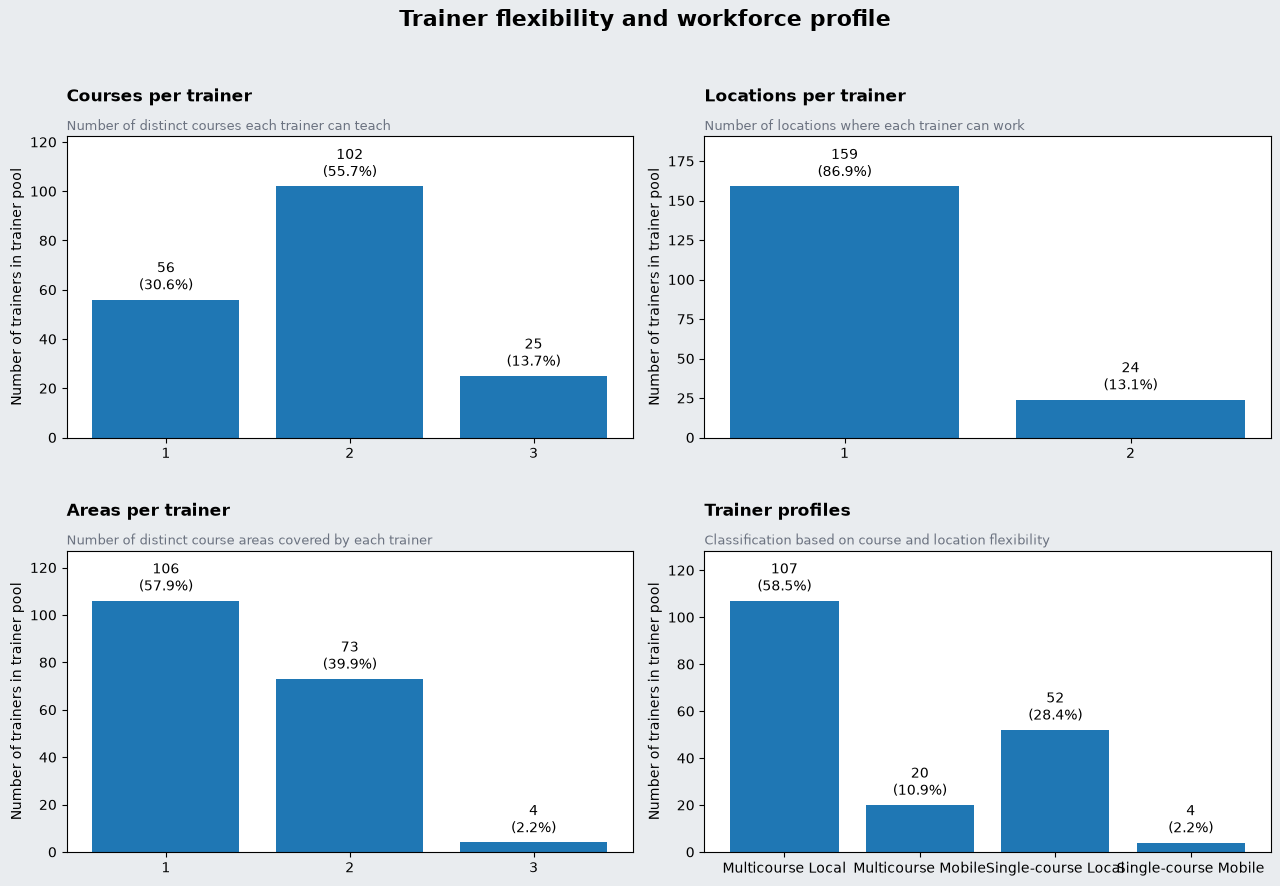

In [18]:
trainer_profile_charts = {
    "course_count": (
        "Courses per trainer",
        "Number of distinct courses each trainer can teach"
    ),
    "local_count": (
        "Locations per trainer",
        "Number of locations where each trainer can work"
    ),
    "area_count": (
        "Areas per trainer",
        "Number of distinct course areas covered by each trainer"
    ),
    "trainer_profile": (
        "Trainer profiles",
        "Classification based on course and location flexibility"
    )
}

plot_workforce_profiles(
    trainer_level,
    trainer_profile_charts,
    "Trainer flexibility and workforce profile",
    "Number of trainers in trainer pool",
    2,
    2
)

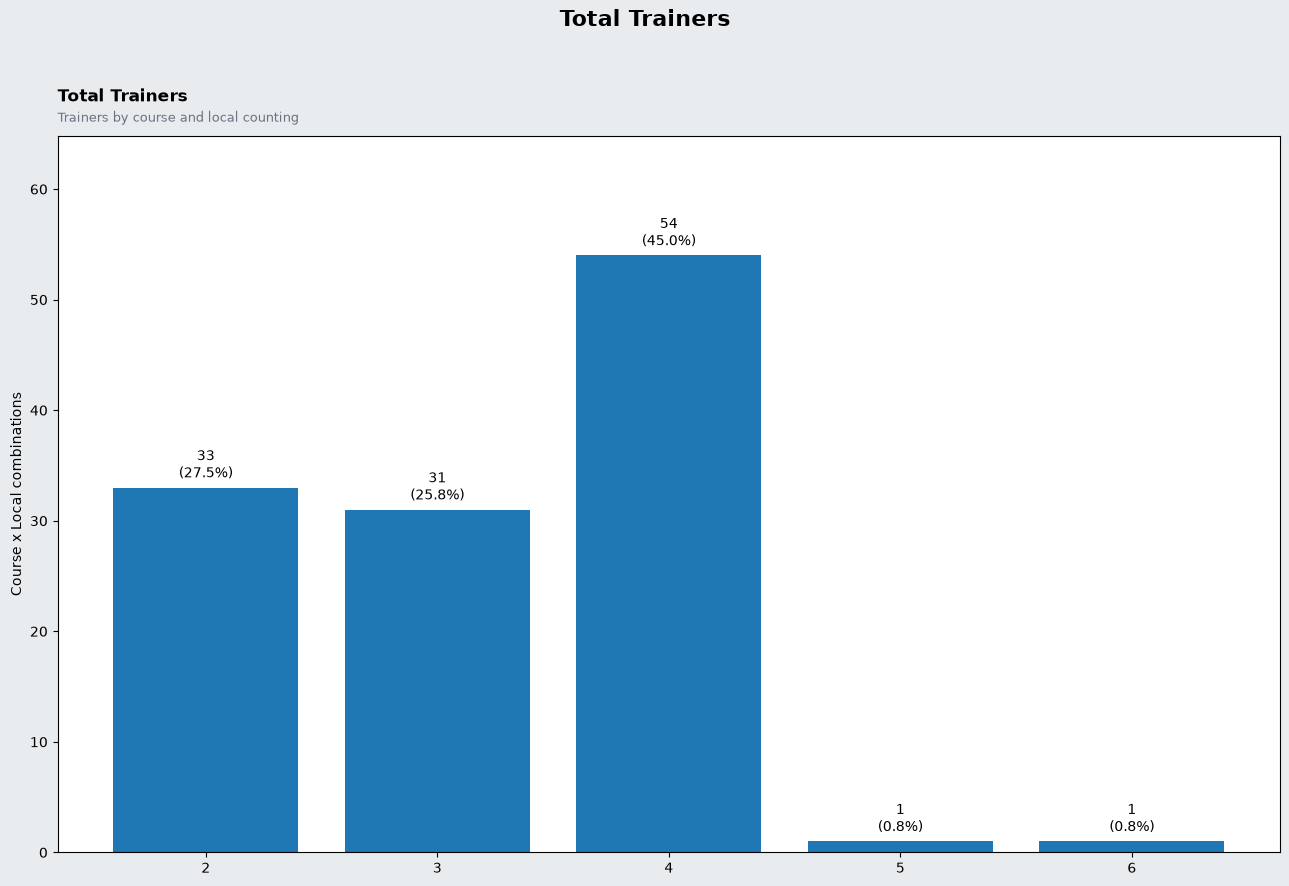

In [19]:
trainer_count_chart = {
    "trainer_count": (
        "Total Trainers", 
        "Trainers by course and local counting"
    )
}

plot_workforce_profiles(course_local_workforce, trainer_count_chart, "Total Trainers", "Course x Local combinations", 1, 1)

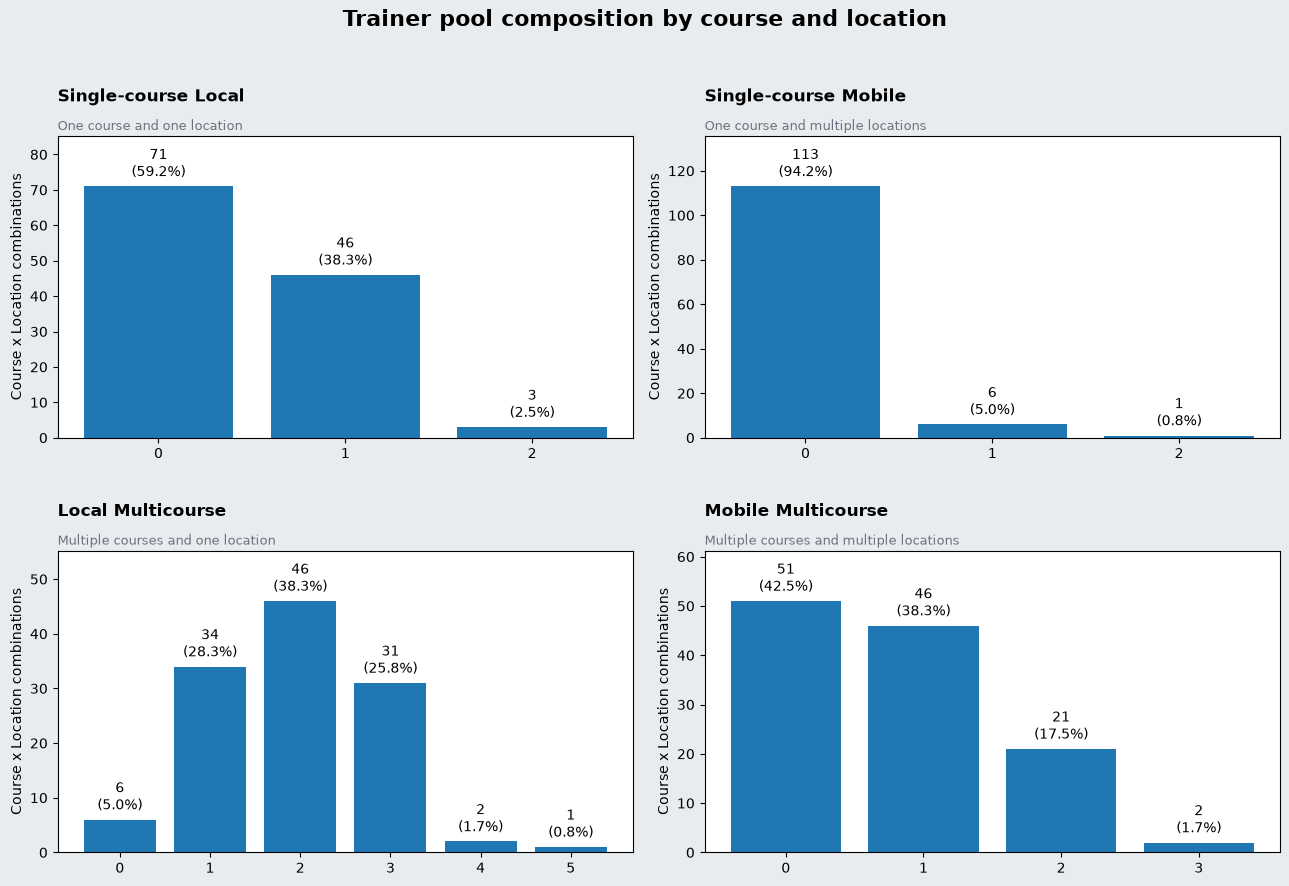

In [20]:
availability_charts = {
    "local_specialist_count": (
        "Single-course Local",
        "One course and one location"
    ),
    "mobile_specialist_count": (
        "Single-course Mobile",
        "One course and multiple locations"
    ),
    "local_multicourse_count": (
        "Local Multicourse",
        "Multiple courses and one location"
    ),
    "mobile_multicourse_count": (
        "Mobile Multicourse",
        "Multiple courses and multiple locations"
    )
}

plot_workforce_profiles(course_local_workforce, availability_charts, "Trainer pool composition by course and location", "Course x Location combinations")

### Workforce profile findings

The trainer pool is predominantly local but flexible across courses:

- 107 trainers (58.5%) are classified as Multicourse Local;
- 52 trainers (28.4%) are Single-course Local;
- 20 trainers (10.9%) are Multicourse Mobile;
- 4 trainers (2.2%) are Single-course Mobile.

This indicates that course flexibility is considerably more common than geographical mobility. Although multicourse trainers broaden the organisation's technical coverage, their capacity may be shared across simultaneous course demands.

Trainer coverage by location is comparatively balanced, ranging from 39 trainers in Centres 1 and 4 to 44 trainers in Centres 2 and 3. However, this overall balance does not prevent individual course-location combinations from having limited coverage.

## Structural workforce vulnerability

Additional indicators are created to identify operational dependence within each course-location combination:

- `backup_trainer_count`: trainers remaining after one trainer is treated as the primary resource;
- `single_trainer_dependency`: combinations covered by only one trainer;
- `low_redundancy`: combinations with no more than two trainers;
- `mobile_backup_count`: trainers potentially available across multiple locations;
- `shared_trainer_count`: trainers registered for multiple courses;
- `pct_shared_trainers`: percentage of the trainer pool whose capacity is shared across courses.

These measures distinguish nominal trainer count from effective structural resilience.

In [21]:
course_local_workforce = (
    course_local_workforce
    .assign(
        backup_trainer_count=lambda df:
            df["trainer_count"].sub(1).clip(lower=0),

        single_trainer_dependency=lambda df:
            df["trainer_count"].eq(1),

        low_redundancy=lambda df:
            df["trainer_count"].le(2),

        mobile_backup_count=lambda df:
            df["mobile_specialist_count"]
            .add(df["mobile_multicourse_count"]),

        shared_trainer_count=lambda df:
            df["local_multicourse_count"]
            .add(df["mobile_multicourse_count"]),

        pct_shared_trainers=lambda df:
            df["shared_trainer_count"]
            .div(df["trainer_count"])
            .mul(100)
            .round(2)
    )
)

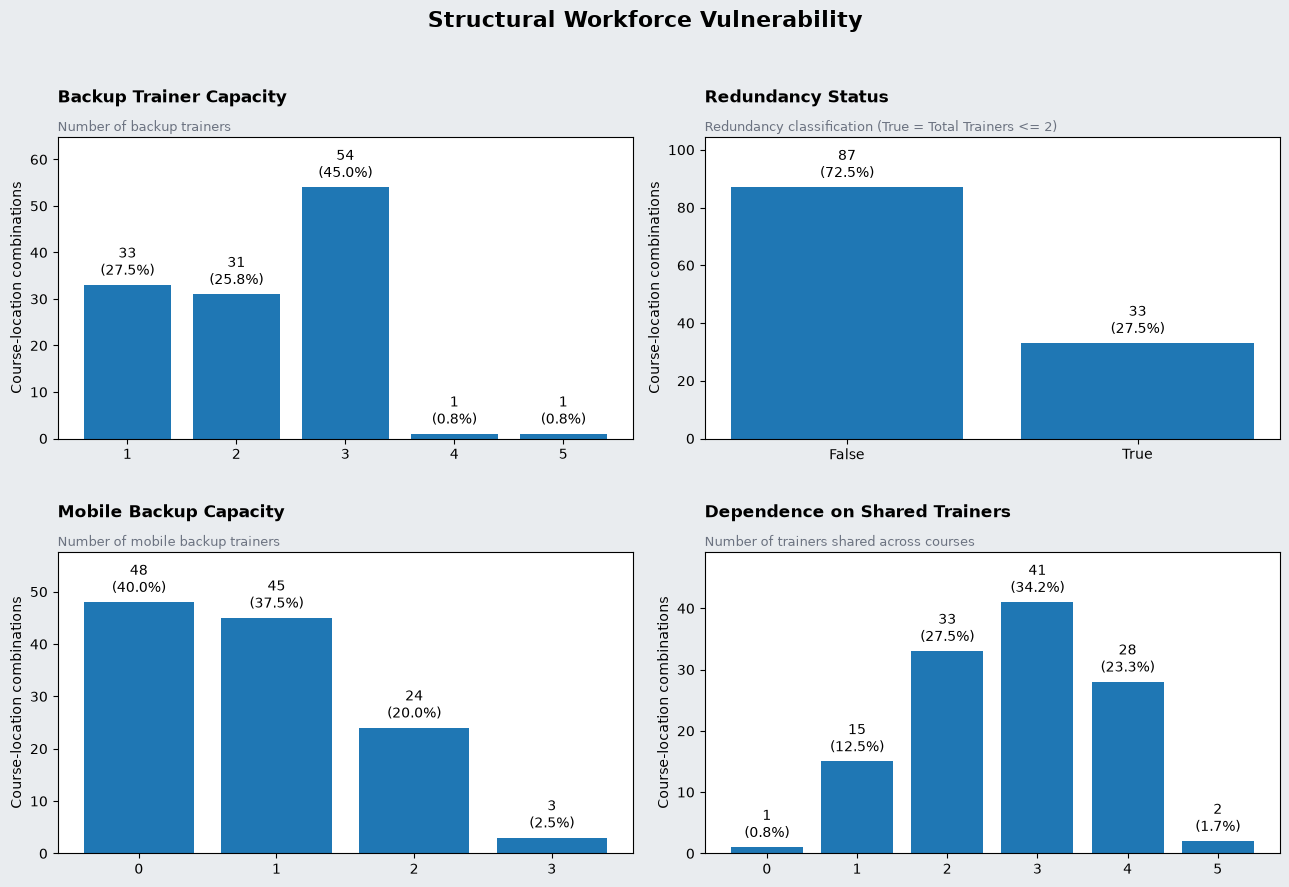

In [22]:
vulnerability_charts = {
    "backup_trainer_count": (
        "Backup Trainer Capacity",
        "Number of backup trainers"
    ),

    "low_redundancy": (
        "Redundancy Status",
        "Redundancy classification (True = Total Trainers <= 2)"
    ),

    "mobile_backup_count": (
        "Mobile Backup Capacity",
        "Number of mobile backup trainers"
    ),

    "shared_trainer_count": (
        "Dependence on Shared Trainers",
        "Number of trainers shared across courses"
    )
}

plot_workforce_profiles(
    df=course_local_workforce,
    charts=vulnerability_charts,
    subtitle="Structural Workforce Vulnerability",
    ylabel="Course-location combinations",
    nrows=2,
    ncols=2
)

## Coverage by course and location

A heatmap compares trainer counts across all course-location combinations. It makes local differences visible even when overall course or centre totals appear sufficient.

Combinations with fewer trainers have less redundancy and are more exposed to unavailability, scheduling conflicts, or dependence on shared trainer capacity.

In [23]:
def plot_heatmap(
    df,
    index,
    columns,
    values,
    title,
    xlabel,
    ylabel,
    colorbar_label,
    figsize=(12, 10),
    x_label_pad=15,
    y_label_pad=20,
    x_tick_pad=8,
    y_tick_pad=8
):
    heatmap_matrix = (
        df.pivot(
            index=index,
            columns=columns,
            values=values
        )
    )

    fig, ax = plt.subplots(
        figsize=figsize,
        facecolor="#E9ECEF"
    )

    heatmap = ax.imshow(
        heatmap_matrix.values,
        aspect="auto"
    )

    ax.set_xticks(
        range(len(heatmap_matrix.columns)),
        labels=heatmap_matrix.columns
    )

    ax.set_yticks(
        range(len(heatmap_matrix.index)),
        labels=heatmap_matrix.index
    )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=20
    )

    ax.set_xlabel(
        xlabel,
        labelpad=x_label_pad
    )

    ax.set_ylabel(
        ylabel,
        labelpad=y_label_pad
    )

    ax.tick_params(
        axis="x",
        pad=x_tick_pad
    )

    ax.tick_params(
        axis="y",
        pad=y_tick_pad
    )

    for row_index in range(heatmap_matrix.shape[0]):
        for column_index in range(heatmap_matrix.shape[1]):

            value = heatmap_matrix.iloc[
                row_index,
                column_index
            ]

            ax.text(
                column_index,
                row_index,
                f"{value:.0f}",
                ha="center",
                va="center"
            )

    colorbar = fig.colorbar(
        heatmap,
        ax=ax
    )

    colorbar.set_label(
        colorbar_label,
        labelpad=12
    )

    plt.tight_layout()
    plt.show()

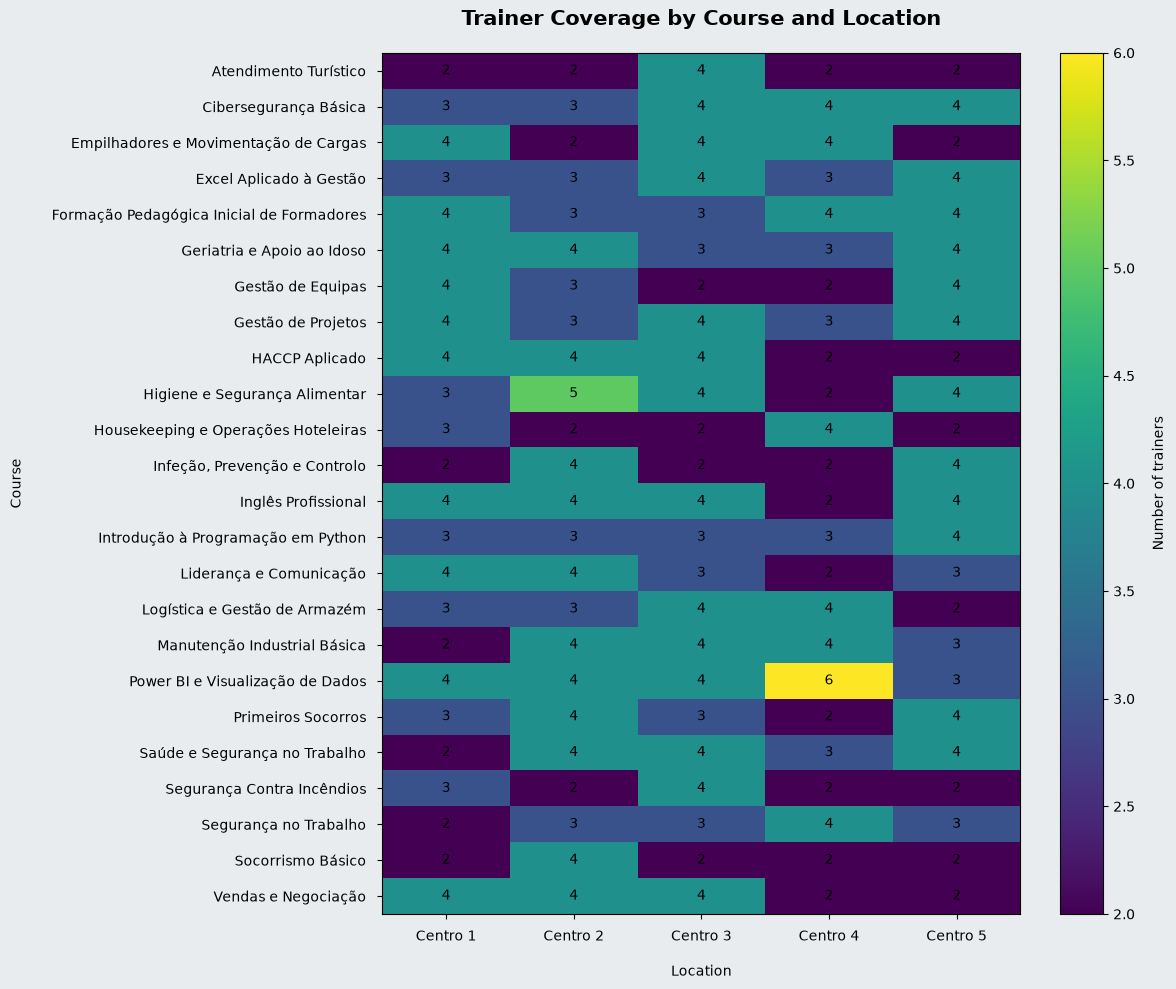

In [24]:
plot_heatmap(
    df=course_local_workforce,
    index="course_name",
    columns="local",
    values="trainer_count",
    title="Trainer Coverage by Course and Location",
    xlabel="Location",
    ylabel="Course",
    colorbar_label="Number of trainers"
)

## Workforce vulnerability score

The workforce score converts trainer coverage and flexibility into an interpretable vulnerability measure ranging from 0 to 100.

It combines three components:

- **Relative scarcity — 60%:** limited trainer coverage relative to the other course-location combinations;
- **Course sharing — 20%:** percentage of trainers registered for multiple courses;
- **Location sharing — 20%:** percentage of trainers registered for multiple locations.

A higher score indicates greater structural vulnerability.

The model gives the greatest weight to trainer scarcity because low absolute coverage creates the most direct continuity risk. Course and location sharing are included because registered trainers may need to divide their capacity across different demands.

In [25]:
WORKFORCE_SCORE_WEIGHTS = {
    "relative_scarcity": 0.60,
    "course_sharing": 0.20,
    "location_sharing": 0.20
}

WORKFORCE_FEATURE_COLUMNS = [
    "course_id",
    "course_name",
    "course_area",
    "local",

    "trainer_count",
    "pct_multicourse_trainers",
    "pct_mobile_trainers",
    "relative_scarcity_score",

    "relative_scarcity_contribution",
    "course_sharing_contribution",
    "location_sharing_contribution",

    "workforce_base_score",
    "workforce_score_percentile",
    "workforce_vulnerability_tier",
    "workforce_main_risk_driver",
    "workforce_base_priority_rank"
]

### Feature construction

For each course-location combination, the model calculates:

- the proportion of trainers registered for multiple courses;
- the proportion of trainers registered for multiple locations;
- a relative scarcity score based on the percentile position of the trainer count.

The scarcity score is relative to the 120 combinations in this dataset. It therefore represents comparative vulnerability rather than a universal minimum staffing threshold.

In [26]:
workforce_features_df = (
    course_local_workforce
    .assign(
        multicourse_trainer_count=lambda df:
            df["local_multicourse_count"]
            .add(df["mobile_multicourse_count"]),

        mobile_trainer_count=lambda df:
            df["mobile_specialist_count"]
            .add(df["mobile_multicourse_count"])
    )
    .assign(
        pct_multicourse_trainers=lambda df:
            df["multicourse_trainer_count"]
            .div(df["trainer_count"])
            .mul(100)
            .round(1),

        pct_mobile_trainers=lambda df:
            df["mobile_trainer_count"]
            .div(df["trainer_count"])
            .mul(100)
            .round(1)
    )
)

workforce_features_df.head()

,course_id,course_name,course_area,local,trainer_count,local_specialist_count,mobile_specialist_count,local_multicourse_count,mobile_multicourse_count,avg_courses_per_trainer,...,backup_trainer_count,single_trainer_dependency,low_redundancy,mobile_backup_count,shared_trainer_count,pct_shared_trainers,multicourse_trainer_count,mobile_trainer_count,pct_multicourse_trainers,pct_mobile_trainers
0,CYB,Cibersegurança Básica,Informática,Centro 1,3,0,0,1,2,2.3,...,2,False,False,2,3,100.00,3,2,100.0,66.7
1,CYB,Cibersegurança Básica,Informática,Centro 2,3,1,0,2,0,1.7,...,2,False,False,0,2,66.67,2,0,66.7,0.0
2,CYB,Cibersegurança Básica,Informática,Centro 3,4,0,0,2,2,2.5,...,3,False,False,2,4,100.00,4,2,100.0,50.0
3,CYB,Cibersegurança Básica,Informática,Centro 4,4,0,0,3,1,2.0,...,3,False,False,1,4,100.00,4,1,100.0,25.0
4,CYB,Cibersegurança Básica,Informática,Centro 5,4,0,0,3,1,2.5,...,3,False,False,1,4,100.00,4,1,100.0,25.0


In [27]:
workforce_scored_features_df = (
    workforce_features_df
    .assign(
        relative_scarcity_score=lambda df:
            df["trainer_count"]
            .rank(
                method="average",
                pct=True,
                ascending=False
            )
            .mul(100)
            .round(1)
    )
)

workforce_scored_features_df[
    [
        "trainer_count",
        "relative_scarcity_score",
        "pct_multicourse_trainers",
        "pct_mobile_trainers"
    ]
].head()

,trainer_count,relative_scarcity_score,pct_multicourse_trainers,pct_mobile_trainers
0,3,60.0,100.0,66.7
1,3,60.0,66.7,0.0
2,4,24.6,100.0,50.0
3,4,24.6,100.0,25.0
4,4,24.6,100.0,25.0


### Weighted contributions

Each component is multiplied by its corresponding weight. The three weighted contributions are then added to produce the `workforce_base_score`.

Because all components are expressed on a 0–100 scale, the final score also remains interpretable within this range.

In [28]:
workforce_scored_features_df = (
    workforce_scored_features_df
    .assign(
        relative_scarcity_contribution=lambda df:
            df["relative_scarcity_score"]
            .mul(WORKFORCE_SCORE_WEIGHTS["relative_scarcity"])
            .round(1),

        course_sharing_contribution=lambda df:
            df["pct_multicourse_trainers"]
            .mul(WORKFORCE_SCORE_WEIGHTS["course_sharing"])
            .round(1),

        location_sharing_contribution=lambda df:
            df["pct_mobile_trainers"]
            .mul(WORKFORCE_SCORE_WEIGHTS["location_sharing"])
            .round(1)
    )
    .assign(
        workforce_base_score=lambda df:
            (
                df["relative_scarcity_contribution"]
                .add(df["course_sharing_contribution"])
                .add(df["location_sharing_contribution"])
            )
            .round(1)
    )
)

workforce_scored_features_df[
    [
        "relative_scarcity_contribution",
        "course_sharing_contribution",
        "location_sharing_contribution",
        "workforce_base_score"
    ]
].head()

,relative_scarcity_contribution,course_sharing_contribution,location_sharing_contribution,workforce_base_score
0,36.0,20.0,13.3,69.3
1,36.0,13.3,0.0,49.3
2,14.8,20.0,10.0,44.8
3,14.8,20.0,5.0,39.8
4,14.8,20.0,5.0,39.8


### Vulnerability classification

The final score is classified into four fixed levels:

- `Low`: 0–25;
- `Lower-middle`: above 25–50;
- `Upper-middle`: above 50–75;
- `High`: above 75–100.

The model also identifies:

- the percentile position of each score;
- the component contributing most to the score;
- the workforce-priority rank.

Tied combinations receive the same dense priority rank.

In [29]:
workforce_scored_features_df = (
    workforce_scored_features_df
    .assign(
        workforce_score_percentile=lambda df:
            df["workforce_base_score"]
            .rank(
                method="average",
                pct=True,
                ascending=True
            )
            .mul(100)
            .round(1)
    )
    .assign(
        workforce_vulnerability_tier=lambda df:
            pd.cut(
                df["workforce_base_score"],
                bins=[0, 25, 50, 75, 100],
                labels=[
                    "Low",
                    "Lower-middle",
                    "Upper-middle",
                    "High"
                ],
                include_lowest=True
            ),

        workforce_main_risk_driver=lambda df:
            df[
                [
                    "relative_scarcity_contribution",
                    "course_sharing_contribution",
                    "location_sharing_contribution"
                ]
            ]
            .idxmax(axis=1)
            .map(
                {
                    "relative_scarcity_contribution":
                        "Trainer scarcity",

                    "course_sharing_contribution":
                        "Multicourse trainers",

                    "location_sharing_contribution":
                        "Mobile trainers"
                }
            )
    )
    .sort_values(
        by="workforce_base_score",
        ascending=False
    )
    .reset_index(drop=True)
    .assign(
        workforce_base_priority_rank=lambda df:
        df["workforce_base_score"]
        .rank(method="dense", ascending=False)
        .astype(int)
    )
    .loc[:, WORKFORCE_FEATURE_COLUMNS]
)

workforce_scored_features_df

,course_id,course_name,course_area,local,trainer_count,pct_multicourse_trainers,pct_mobile_trainers,relative_scarcity_score,relative_scarcity_contribution,course_sharing_contribution,location_sharing_contribution,workforce_base_score,workforce_score_percentile,workforce_vulnerability_tier,workforce_main_risk_driver,workforce_base_priority_rank
0,HOT,Housekeeping e Operações Hoteleiras,Turismo,Centro 3,2,100.0,50.0,86.7,52.0,20.0,10.0,82.0,97.9,High,Trainer scarcity,1
1,TUR,Atendimento Turístico,Turismo,Centro 4,2,100.0,50.0,86.7,52.0,20.0,10.0,82.0,97.9,High,Trainer scarcity,1
2,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 2,2,100.0,50.0,86.7,52.0,20.0,10.0,82.0,97.9,High,Trainer scarcity,1
3,SST,Saúde e Segurança no Trabalho,Segurança,Centro 1,2,100.0,50.0,86.7,52.0,20.0,10.0,82.0,97.9,High,Trainer scarcity,1
4,ING,Inglês Profissional,Línguas,Centro 4,2,100.0,50.0,86.7,52.0,20.0,10.0,82.0,97.9,High,Trainer scarcity,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 5,4,75.0,0.0,24.6,14.8,15.0,0.0,29.8,5.4,Lower-middle,Multicourse trainers,15
116,ING,Inglês Profissional,Línguas,Centro 2,4,75.0,0.0,24.6,14.8,15.0,0.0,29.8,5.4,Lower-middle,Multicourse trainers,15
117,HAC,Higiene e Segurança Alimentar,Alimentar,Centro 2,5,100.0,40.0,1.7,1.0,20.0,8.0,29.0,2.5,Lower-middle,Multicourse trainers,16
118,HAC,Higiene e Segurança Alimentar,Alimentar,Centro 5,4,50.0,0.0,24.6,14.8,10.0,0.0,24.8,1.7,Low,Trainer scarcity,17


## Workforce vulnerability results

The scored results are examined through:

- the distribution of vulnerability levels;
- the main risk driver;
- the distribution of vulnerability by location;
- the courses exposed across the greatest number of centres.

This analysis identifies whether workforce pressure is isolated to individual combinations or repeated across several locations.

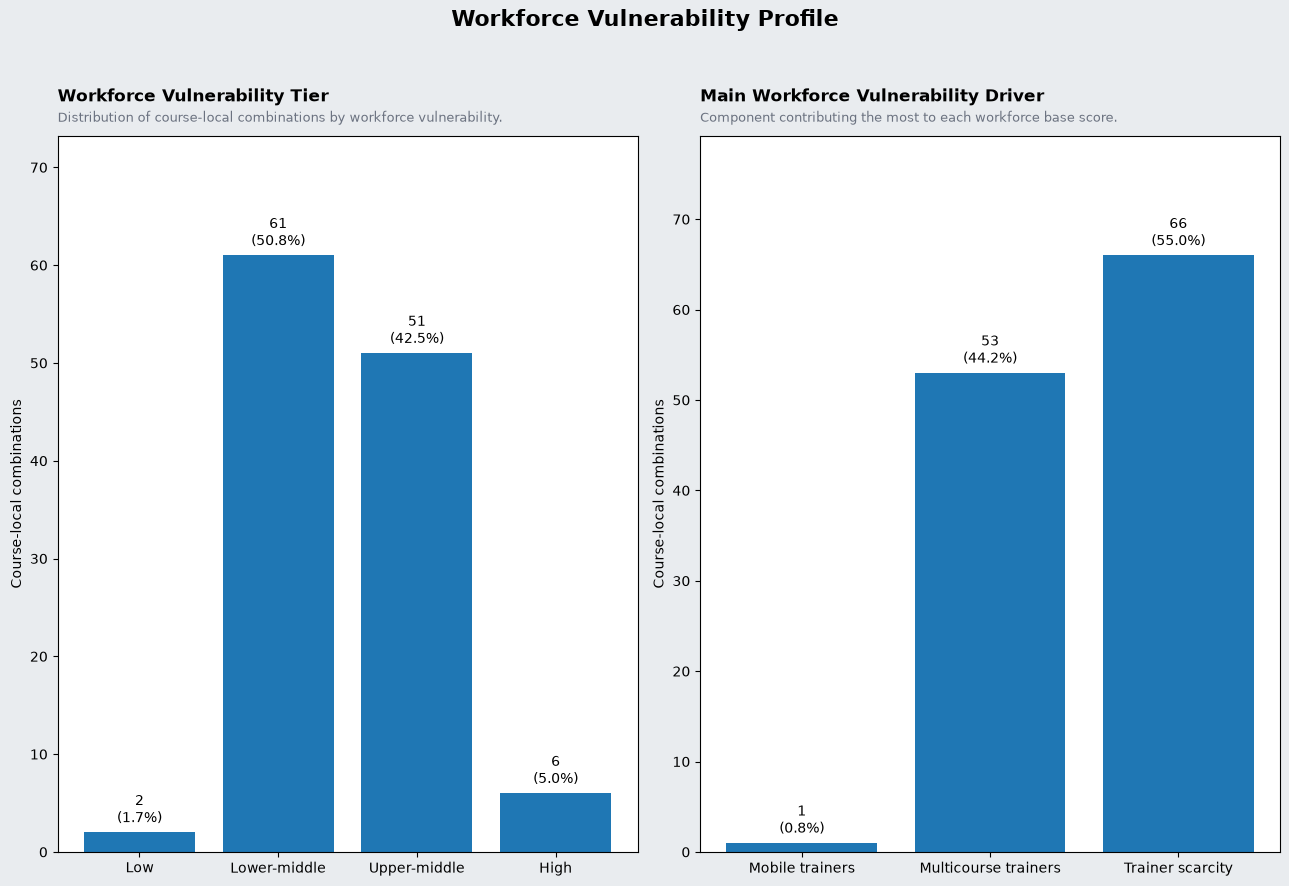

In [30]:
scores_charts = {
    "workforce_vulnerability_tier": (
        "Workforce Vulnerability Tier",
        "Distribution of course-local combinations by workforce vulnerability."
    ),

    "workforce_main_risk_driver": (
        "Main Workforce Vulnerability Driver",
        "Component contributing the most to each workforce base score."
    )
}

plot_workforce_profiles(
    df=workforce_scored_features_df,
    charts=scores_charts,
    subtitle="Workforce Vulnerability Profile",
    ylabel="Course-local combinations",
    nrows=1,
    ncols=2
)

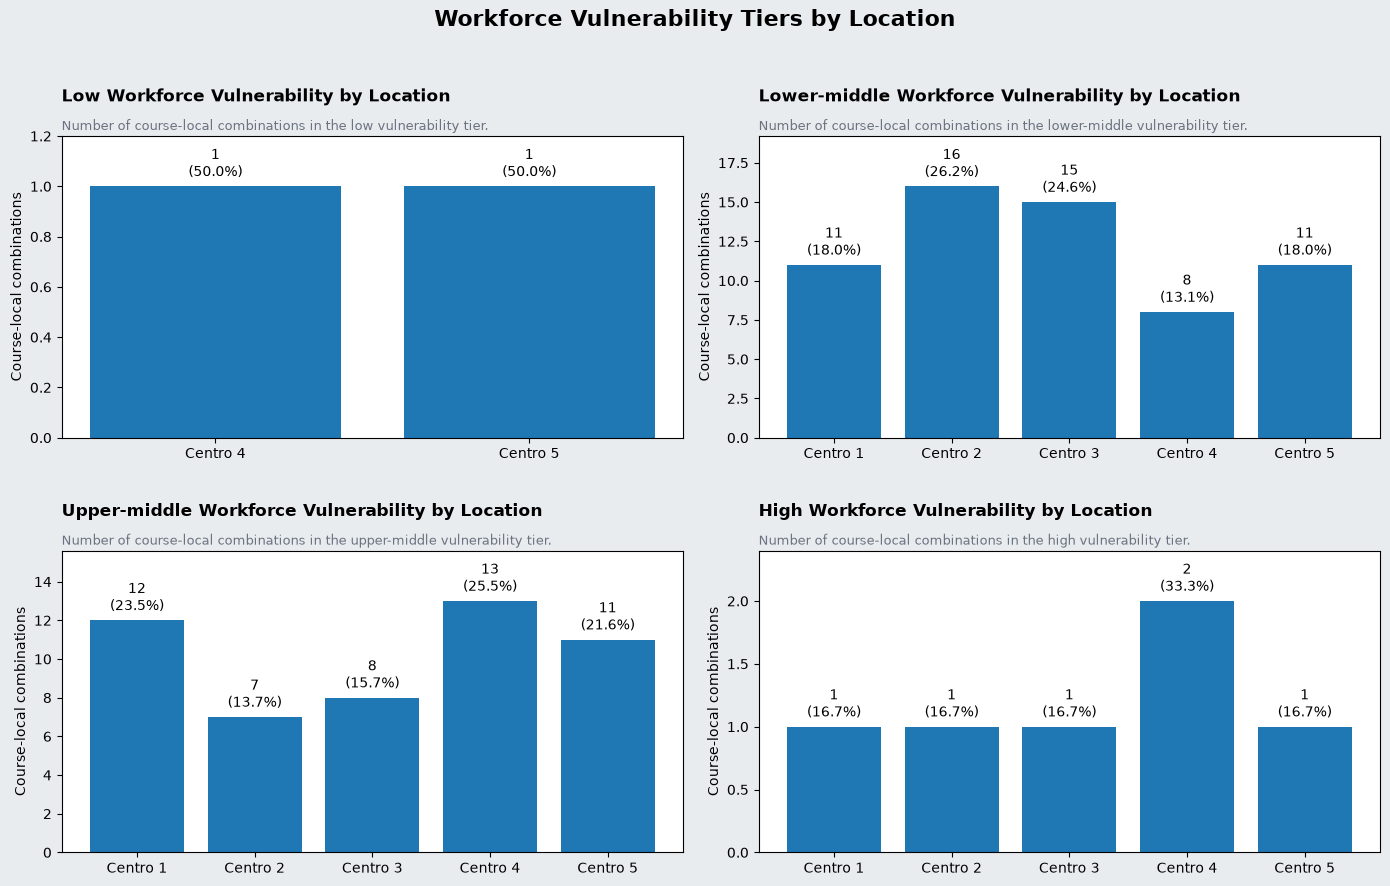

In [31]:
vulnerability_tiers = [
    "Low",
    "Lower-middle",
    "Upper-middle",
    "High"
]

workforce_location_tier_df = pd.concat(
    {
        f"{tier.lower()}_local": (
            workforce_scored_features_df
            .loc[
                workforce_scored_features_df["workforce_vulnerability_tier"]
                .eq(tier),
                "local"
            ]
            .reset_index(drop=True)
        )
        for tier in vulnerability_tiers
    },
    axis=1
)

local_tier_charts = {
    f"{tier.lower()}_local": (
        f"{tier} Workforce Vulnerability by Location",
        f"Number of course-local combinations in the {tier.lower()} vulnerability tier."
    )
    for tier in vulnerability_tiers
}

plot_workforce_profiles(
    df=workforce_location_tier_df,
    charts=local_tier_charts,
    subtitle="Workforce Vulnerability Tiers by Location",
    ylabel="Course-local combinations",
    nrows=2,
    ncols=2,
    figsize=(14,9)
)

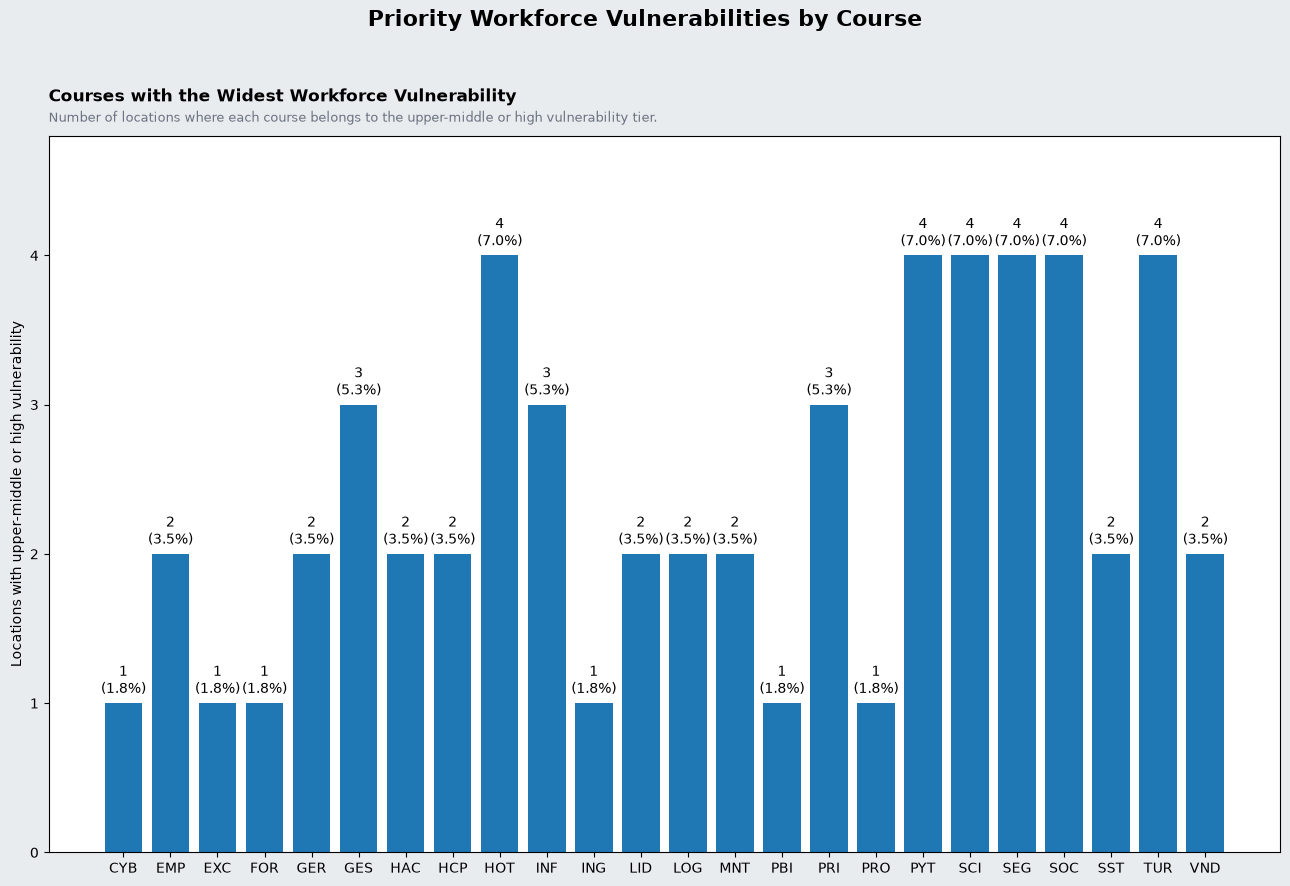

In [32]:
priority_courses_df = (
    workforce_scored_features_df
    .loc[
        workforce_scored_features_df["workforce_vulnerability_tier"]
        .isin(["Upper-middle", "High"]),
        ["course_id"]
    ]
    .copy()
)

course_vulnerability_charts = {
    "course_id": (
        "Courses with the Widest Workforce Vulnerability",
        "Number of locations where each course belongs to the upper-middle or high vulnerability tier."
    )
}

plot_workforce_profiles(
    df=priority_courses_df,
    charts=course_vulnerability_charts,
    subtitle="Priority Workforce Vulnerabilities by Course",
    ylabel="Locations with upper-middle or high vulnerability",
    nrows=1,
    ncols=1
)

## Key workforce findings

Of the 120 course-location combinations:

- 6 are classified as High vulnerability;
- 51 are Upper-middle;
- 61 are Lower-middle;
- 2 are Low.

Trainer scarcity is the main risk driver for 66 combinations, while dependence on multicourse trainers is the main driver for 53. Geographical mobility is the leading driver in only one combination.

The six High-vulnerability combinations each have only two eligible trainers and depend substantially on trainers whose capacity is shared across courses or locations:

- Empilhadores e Movimentação de Cargas — Centre 2;
- Inglês Profissional — Centre 4;
- Housekeeping e Operações Hoteleiras — Centre 3;
- Logística e Gestão de Armazém — Centre 5;
- Atendimento Turístico — Centre 4;
- Saúde e Segurança no Trabalho — Centre 1.

Centre 4 contains the largest number of Upper-middle or High-vulnerability combinations, followed by Centres 1 and 5.

These findings indicate where the existing trainer pool is structurally most exposed. They do not independently establish a recruitment requirement, because operational and commercial demand must also be considered.

## Export workforce scores

The workforce features, weighted contributions, vulnerability levels, main risk drivers, and priority ranks are exported to:

`data/scores/workforce_scored_features.csv`

This dataset becomes the workforce input for the final hiring-priority model.

In [33]:
workforce_scored_features_df.to_csv(
    SCORES_DATA_DIR / "workforce_scored_features.csv",
    index=False,
    encoding="utf-8"
)

## Workforce analysis outcome

The workforce analysis transformed trainer registrations into a structured assessment of coverage, flexibility, redundancy, and shared-capacity risk for all 120 course-location combinations.

The results show that overall trainer availability can conceal important local vulnerabilities. A combination may have registered trainers while remaining exposed because coverage is limited or depends on professionals shared across several courses or centres.

The workforce score will therefore be combined with training-activity and commercial-pressure scores before final recruitment priorities are determined.